Using device: cpu
Loading and merging multiple region files...
Merged Data Shape: (5270, 5)
Features: ['TESTING SHEET.CSV', 'hour', 'day_of_week', 'month', 'day_of_year']
Time Range: 2022-12-12 05:30:00 to 2023-04-01 00:00:00
Created sequences. X shape: (5246, 24, 5), y shape: (5246,)
Model input features: 5


C:\Users\arjun\AppData\Local\Temp\ipykernel_20860\2348016663.py:124: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  main_df = main_df.fillna(method='ffill').fillna(method='bfill')


Epoch [1/20] Avg Loss: 0.050324 | Train RMSE: 0.2243
Epoch [2/20] Avg Loss: 0.015941 | Train RMSE: 0.1263
Epoch [3/20] Avg Loss: 0.014510 | Train RMSE: 0.1205
Epoch [4/20] Avg Loss: 0.013027 | Train RMSE: 0.1141
Epoch [5/20] Avg Loss: 0.010977 | Train RMSE: 0.1048
Epoch [6/20] Avg Loss: 0.011668 | Train RMSE: 0.1080
Epoch [7/20] Avg Loss: 0.008947 | Train RMSE: 0.0946
Epoch [8/20] Avg Loss: 0.008118 | Train RMSE: 0.0901
Epoch [9/20] Avg Loss: 0.007338 | Train RMSE: 0.0857
Epoch [10/20] Avg Loss: 0.007390 | Train RMSE: 0.0860
Epoch [11/20] Avg Loss: 0.007406 | Train RMSE: 0.0861
Epoch [12/20] Avg Loss: 0.007506 | Train RMSE: 0.0866
Epoch [13/20] Avg Loss: 0.007737 | Train RMSE: 0.0880
Epoch [14/20] Avg Loss: 0.007326 | Train RMSE: 0.0856
Epoch [15/20] Avg Loss: 0.007389 | Train RMSE: 0.0860
Epoch [16/20] Avg Loss: 0.006520 | Train RMSE: 0.0807
Epoch [17/20] Avg Loss: 0.007008 | Train RMSE: 0.0837
Epoch [18/20] Avg Loss: 0.006678 | Train RMSE: 0.0817
Epoch [19/20] Avg Loss: 0.006289 | Tr

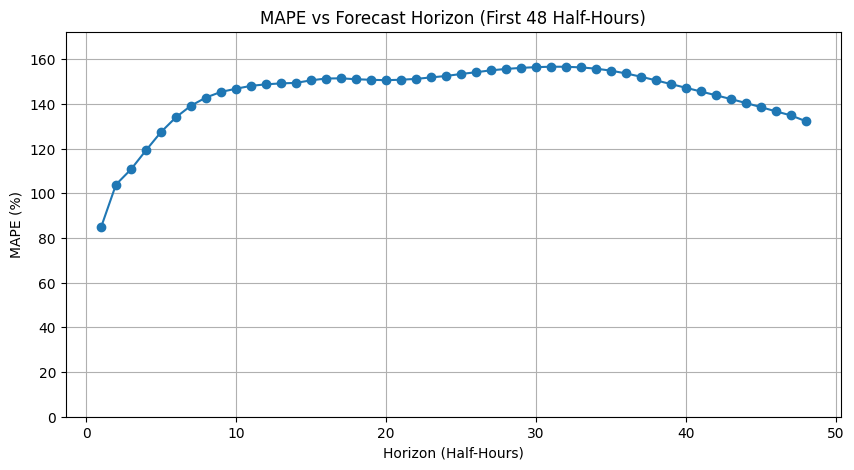

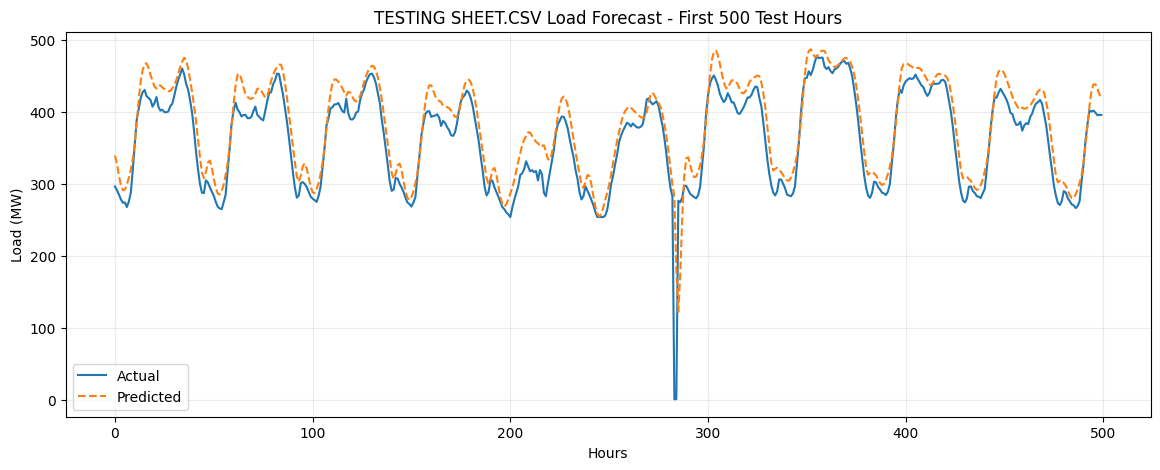

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os
import random

# ==========================================
# 1. CONFIGURATION & TOGGLES
# ==========================================
class Config:
    FORCE_CPU = False

    SEQ_LENGTH = 24
    PREDICT_HORIZON = 1
    HIDDEN_SIZE = 128
    NUM_LAYERS = 2
    DROPOUT = 0.2
    BATCH_SIZE = 64
    LEARNING_RATE = 0.001
    EPOCHS = 20

    DATA_FILES = ['data/Testing sheet.csv',]

    TARGET_REGION = 'TESTING SHEET.CSV'

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

def get_device():
    if Config.FORCE_CPU:
        return torch.device("cpu")
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
print("Using device:", DEVICE)

# ==========================================
# 2. DATA PREPROCESSING (MULTI-FILE)
# ==========================================
def load_and_process_data():
    print("Loading and merging multiple region files...")
    main_df = None
    loaded_regions = []

    for file_path in Config.DATA_FILES:
        # Accept absolute or relative paths
        if os.path.isabs(file_path):
            path = file_path
        else:
            # helpful fallback: look in current working dir or kaggle input dir
            path = os.path.join(os.getcwd(), file_path)
            if not os.path.exists(path):
                path = os.path.join('/kaggle/input/hourly-energy-consumption', os.path.basename(file_path))

        if not os.path.exists(path):
            print(f"Warning: {path} not found. Skipping.")
            continue

        df = pd.read_csv(path)

        # Robust datetime detection
        dt_col = None
        for candidate in ['Datetime', 'datetime', 'Date', 'date', df.columns[0]]:
            if candidate in df.columns:
                dt_col = candidate
                break
        if dt_col is None:
            raise ValueError(f"No datetime-like column found in {path}")

        df = df.rename(columns={dt_col: 'Datetime'})
        df['Datetime'] = pd.to_datetime(df['Datetime'])
        df = df.set_index('Datetime')
        df = df.sort_index()
        df = df[~df.index.duplicated(keep='first')]

        # Robust target column detection (find numeric column, prefer 'MW')
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if not numeric_cols:
            print(f"Warning: no numeric columns found in {path}. Skipping.")
            continue
        col_name = next((c for c in numeric_cols if 'MW' in c or 'mw' in c), numeric_cols[0])

        # region name from filename (basename, not whole path)
        region_name = os.path.basename(path).split('_')[0].upper()
        df = df.rename(columns={col_name: region_name})

        # Keep only the renamed column (plus optionally other numeric columns if wanted)
        df = df[[region_name]]

        # Merge: use outer join to preserve timestamps, we'll interpolate later
        if main_df is None:
            main_df = df
        else:
            main_df = main_df.merge(df, left_index=True, right_index=True, how='outer')

        loaded_regions.append(region_name)

    if main_df is None or main_df.empty:
        raise ValueError("No data loaded. Check file paths and dataset availability.")

    # Time features
    main_df = main_df.sort_index()
    main_df['hour'] = main_df.index.hour
    main_df['day_of_week'] = main_df.index.dayofweek
    main_df['month'] = main_df.index.month
    main_df['day_of_year'] = main_df.index.dayofyear

    # Interpolate and fill remaining NaNs
    main_df = main_df.interpolate(method='time', limit_direction='both')
    main_df = main_df.fillna(method='ffill').fillna(method='bfill')

    # Move target region to column 0
    cols = list(main_df.columns)
    target = Config.TARGET_REGION.upper()
    if target in cols:
        cols.insert(0, cols.pop(cols.index(target)))
        main_df = main_df[cols]
    else:
        raise ValueError(f"Target region {target} not found. Loaded regions: {loaded_regions}")

    print(f"Merged Data Shape: {main_df.shape}")
    print(f"Features: {list(main_df.columns)}")
    print(f"Time Range: {main_df.index.min()} to {main_df.index.max()}")
    return main_df

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

def create_sequences(data_values, seq_length):
    sequences = []
    labels = []
    target_idx = 0
    for i in range(len(data_values) - seq_length):
        seq = data_values[i : i + seq_length]
        label = data_values[i + seq_length, target_idx]
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)

# ==========================================
# 3. MODEL DEFINITION
# ==========================================
class MultiRegionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1, dropout=0.2):
        super(MultiRegionLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        effective_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=effective_dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # allocate h0 and c0 on same device as x (works for cpu/cuda/mps)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# ==========================================
# 4. TRAINING & EVALUATION
# ==========================================
def train_model():
    df = load_and_process_data()

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df.values)

    X, y = create_sequences(scaled_data, Config.SEQ_LENGTH)
    print(f"Created sequences. X shape: {X.shape}, y shape: {y.shape}")

    split_idx = int(len(X) * 0.90)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    train_loader = DataLoader(TimeSeriesDataset(X_train, y_train),
                              batch_size=Config.BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(TimeSeriesDataset(X_test, y_test),
                             batch_size=Config.BATCH_SIZE, shuffle=False)

    input_size = X.shape[2]
    model = MultiRegionLSTM(input_size, Config.HIDDEN_SIZE, Config.NUM_LAYERS, dropout=Config.DROPOUT).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)

    print(f"Model input features: {input_size}")

    train_losses = []
    for epoch in range(Config.EPOCHS):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches if n_batches > 0 else 0.0
        train_losses.append(avg_loss)
        train_rmse = np.sqrt(avg_loss)
        print(f"Epoch [{epoch+1}/{Config.EPOCHS}] Avg Loss: {avg_loss:.6f} | Train RMSE: {train_rmse:.4f}")

    # Evaluation
    model.eval()
    preds_list, acts_list = [], []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(DEVICE)
            out = model(batch_X).cpu().numpy().reshape(-1)
            preds_list.append(out)
            acts_list.append(batch_y.numpy().reshape(-1))

    preds = np.concatenate(preds_list)
    acts = np.concatenate(acts_list)

    # Inverse transform
    n = len(preds)
    n_features = scaled_data.shape[1]
    dummy_pred = np.zeros((n, n_features))
    dummy_act = np.zeros((n, n_features))
    dummy_pred[:, 0] = preds
    dummy_act[:, 0] = acts
    inv_pred = scaler.inverse_transform(dummy_pred)[:, 0]
    inv_act = scaler.inverse_transform(dummy_act)[:, 0]

    mae = np.mean(np.abs(inv_pred - inv_act))
    rmse = np.sqrt(np.mean((inv_pred - inv_act) ** 2))
    # safe MAPE
    nonzero = inv_act != 0
    mape = np.mean(np.abs((inv_act[nonzero] - inv_pred[nonzero]) / inv_act[nonzero])) * 100 if nonzero.sum() > 0 else np.nan

    print("\nFINAL RESULTS")
    print(f"RMSE: {rmse:.2f} MW")
    print(f"MAE : {mae:.2f} MW")
    print(f"MAPE: {mape if not np.isnan(mape) else 'N/A'}%")

    # MAPE vs HORIZON (FIRST 48 HALF-HOURS)
    # Assumes the target load is column 0 in scaled_data / X_test
    # ==========================================

    H = 48
    H = min(H, len(X_test) - 1)  # safety

    horizon_errors = [[] for _ in range(H)]

    model.eval()
    with torch.no_grad():
        # Rolling origins over the test set
        for i in range(len(X_test) - H):
            seq = X_test[i].copy()   # shape: (SEQ_LENGTH, num_features)
            preds = []

            # Recursive forecast for 1..H
            for h in range(H):
                inp = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(DEVICE)
                pred = model(inp).cpu().numpy().reshape(-1)[0]
                preds.append(pred)

                # Roll forward: keep exogenous features fixed at last observed row
                next_row = seq[-1].copy()
                next_row[0] = pred   # update only target feature
                seq = np.vstack([seq[1:], next_row])

            actual = y_test[i:i+H]
            if len(actual) < H:
                continue

            # Inverse transform only target column (column 0)
            dummy_pred = np.zeros((H, n_features))
            dummy_act  = np.zeros((H, n_features))
            dummy_pred[:, 0] = preds
            dummy_act[:, 0]  = actual

            inv_pred_h = scaler.inverse_transform(dummy_pred)[:, 0]
            inv_act_h  = scaler.inverse_transform(dummy_act)[:, 0]

            for h in range(H):
                denom = max(abs(inv_act_h[h]), 1e-6)
                ape = abs(inv_act_h[h] - inv_pred_h[h]) / denom * 100.0
                horizon_errors[h].append(ape)

    # Mean MAPE per horizon
    mape_per_horizon = [
        np.mean(errs) if len(errs) > 0 else np.nan
        for errs in horizon_errors
    ]

    # Debug first
    y = np.asarray(mape_per_horizon, dtype=float)
    print("MAPE min/max:", np.nanmin(y), np.nanmax(y))

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, H + 1), y, marker='o')
    plt.xlabel("Horizon (Half-Hours)")
    plt.ylabel("MAPE (%)")
    plt.title("MAPE vs Forecast Horizon (First 48 Half-Hours)")
    plt.grid(True)

    # Use a higher limit or remove it entirely
    plt.ylim(0, max(100, np.nanmax(y) * 1.1))

    plt.show()

    # Plot first N points
    limit = min(500, len(inv_act))
    plt.figure(figsize=(14,5))
    plt.plot(inv_act[:limit], label='Actual')
    plt.plot(inv_pred[:limit], label='Predicted', linestyle='--')
    plt.title(f"{Config.TARGET_REGION} Load Forecast - First {limit} Test Hours")
    plt.xlabel("Hours")
    plt.ylabel("Load (MW)")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    return model, scaler, train_losses

if __name__ == "__main__":
    train_model()
